<a href="https://colab.research.google.com/github/BhavyaKansal20/AAGNIChatbot/blob/main/final_training_loop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import pandas as pd
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

torch.backends.cudnn.benchmark = True

# ========================================================
# 1. THE LOSS FUNCTION (WEIBULL 5-YEAR SURVIVAL)
# ========================================================
class CostSensitiveWeibullLoss(nn.Module):
    def __init__(self, k=5):
        super().__init__()
        self.k = k
        self.alpha_prior = torch.tensor([1.5, 3.0, 6.0, 12.0, 20.0], dtype=torch.float32)
        self.beta_prior = torch.tensor([2.0, 2.0, 2.0, 2.0, 2.0], dtype=torch.float32)

    def forward(self, logits, targets):
        phi = torch.softmax(logits, dim=1)
        device = logits.device
        alpha = self.alpha_prior.to(device)

        ce_loss = F.cross_entropy(logits, targets)
        t_expected = alpha[targets]
        t_pred = torch.sum(phi * alpha, dim=1)
        time_penalty = F.mse_loss(t_pred, t_expected)

        return ce_loss + 0.1 * time_penalty

# ========================================================
# 2. 110% VISION-FIRST ARCHITECTURE (Residual Verification)
# ========================================================
class SequentialClinicalAI(nn.Module):
    def __init__(self, num_nodes=5):
        super().__init__()
        # Ultra-Deep Vision Extractor
        self.vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
        img_dim = self.vit.heads.head.in_features
        self.vit.heads = nn.Identity()

        self.vision_bottleneck = nn.Linear(img_dim, 256)
        self.vision_aux_head = nn.Linear(256, num_nodes)

        self.tabular_mlp = nn.Sequential(
            nn.Linear(4, 64), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Linear(64, 32)
        )

        # 👑 GUARANTEE: Tabular is ONLY a modifier, not the decision maker
        self.tabular_modifier = nn.Linear(32, num_nodes)
        self.verification_gate = nn.Linear(32, 1)

    def forward(self, image, tabular):
        # PHASE 1: Pure Vision Deep Scan
        raw_img_feat = self.vit(image)
        retinal_vector = torch.relu(self.vision_bottleneck(raw_img_feat))
        vision_logits = self.vision_aux_head(retinal_vector)

        # PHASE 2: Tabular Fetch
        tabular_vector = self.tabular_mlp(tabular)

        # PHASE 3: Match & Verify (The Formula that seals Tabular Data)
        tab_mod = self.tabular_modifier(tabular_vector)
        gate = torch.sigmoid(self.verification_gate(tabular_vector))

        # Final Prediction is strictly anchored to Vision
        final_logits = vision_logits + (tab_mod * gate)

        if self.training: return final_logits, vision_logits
        else: return torch.softmax(final_logits, dim=1)

# ========================================================
# 3. CLINICAL DATALOADER (WITH CLAHE VESSEL ENHANCEMENT)
# ========================================================
class ClinicalRetinaDataset(Dataset):
    def __init__(self, csv_file, img_dir):
        self.data = pd.read_csv(csv_file)
        self.img_dir = img_dir

        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

        self.min_vals = np.array([16.0, 15.0, 90.0, 100.0], dtype=np.float32)
        self.max_vals = np.array([80.0, 50.0, 200.0, 350.0], dtype=np.float32)

        self.extensions = ['.jpeg', '.jpg', '.png', '.webp', '.tiff', '.bmp', '.JPEG', '.JPG', '.PNG']

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        img_col = 'image' if 'image' in row else 'image_id' if 'image_id' in row else self.data.columns[0]
        img_id = str(row[img_col])

        img_path = None
        for ext in self.extensions:
            temp_path = os.path.join(self.img_dir, img_id + ext)
            if os.path.exists(temp_path):
                img_path = temp_path
                break

        image = None
        if img_path is not None:
            image = cv2.imread(img_path)

        if image is None:
            image = np.zeros((224, 224, 3), dtype=np.uint8)
        else:
            # 👑 GUARANTEE: CLAHE Medical Enhancement (Brings out micro-vessels!)
            clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
            lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
            l, a, b = cv2.split(lab)
            cl = clahe.apply(l)
            image = cv2.cvtColor(cv2.merge((cl, a, b)), cv2.COLOR_LAB2RGB)

        t_img = self.transform(Image.fromarray(image))

        # Tabular Fallback
        try:
            vitals = row[['age', 'bmi', 'sys_bp', 'chol']].values.astype(np.float32)
        except:
            vitals = np.array([np.random.randint(40,75), np.random.randint(20,35), np.random.randint(110,160), np.random.randint(150,250)], dtype=np.float32)

        scaled_vitals = (vitals - self.min_vals) / (self.max_vals - self.min_vals)
        t_tab = torch.tensor(scaled_vitals, dtype=torch.float32)

        label_col = 'level' if 'level' in row else 'diagnosis' if 'diagnosis' in row else self.data.columns[1]
        label = int(row[label_col])

        return t_img, t_tab, label

# ========================================================
# 4. AMP TURBO TRAINING LOOP (CRASH-PROOF)
# ========================================================
CSV_PATH = '/kaggle/input/datasets/mohlamin/resized-eyepacs-diabetic-retinopathy-dataset/original_train_labels.csv'
IMG_DIR = '/kaggle/input/datasets/mohlamin/resized-eyepacs-diabetic-retinopathy-dataset/Images'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔥 Training Engine Started on: {device.type.upper()}")

train_dataset = ClinicalRetinaDataset(csv_file=CSV_PATH, img_dir=IMG_DIR)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)

model = SequentialClinicalAI().to(device)
criterion = CostSensitiveWeibullLoss(k=5).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)

scaler = torch.amp.GradScaler(device='cuda') if torch.cuda.is_available() else None

EPOCHS = 10
try:
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0

        for batch_idx, (images, vitals, labels) in enumerate(train_loader):
            images, vitals, labels = images.to(device), vitals.to(device), labels.to(device)
            optimizer.zero_grad()

            if scaler:
                with torch.amp.autocast(device_type='cuda'):
                    final_logits, vision_logits = model(images, vitals)
                    loss_final = criterion(final_logits, labels)
                    loss_vision = criterion(vision_logits, labels)
                    loss = (0.80 * loss_vision) + (0.20 * loss_final)

                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                final_logits, vision_logits = model(images, vitals)
                loss_final = criterion(final_logits, labels)
                loss_vision = criterion(vision_logits, labels)
                loss = (0.80 * loss_vision) + (0.20 * loss_final)
                loss.backward()
                optimizer.step()

            total_loss += loss.item()

            if batch_idx % 50 == 0:
                print(f"Epoch [{epoch+1}/{EPOCHS}] Batch {batch_idx} | Vision Loss: {loss_vision.item():.4f} | Final Loss: {loss_final.item():.4f}")

        print(f"✅ Epoch {epoch+1} Completed | Avg Loss: {total_loss/len(train_loader):.4f}")
        torch.save(model.state_dict(), f"VisionFirst_ClinicalAI_Epoch_{epoch+1}.pth")

except KeyboardInterrupt:
    print("\n⚠️ Training Interrupted by User! Saving current progress...")
    torch.save(model.state_dict(), "VisionFirst_ClinicalAI_INTERRUPTED.pth")
    print("💾 Emergency Checkpoint Saved!")
except Exception as e:
    print(f"\n❌ FATAL ERROR CAUGHT: {e}")

🔥 Training Engine Started on: CUDA
Epoch [1/10] Batch 0 | Vision Loss: 5.0928 | Final Loss: 5.2116
Epoch [1/10] Batch 50 | Vision Loss: 1.5813 | Final Loss: 1.5672
Epoch [1/10] Batch 100 | Vision Loss: 2.3470 | Final Loss: 2.3578
Epoch [1/10] Batch 150 | Vision Loss: 3.3474 | Final Loss: 3.3632
Epoch [1/10] Batch 200 | Vision Loss: 1.3050 | Final Loss: 1.3199
Epoch [1/10] Batch 250 | Vision Loss: 1.3622 | Final Loss: 1.3582
Epoch [1/10] Batch 300 | Vision Loss: 3.8760 | Final Loss: 3.9013
Epoch [1/10] Batch 350 | Vision Loss: 1.3615 | Final Loss: 1.3597
Epoch [1/10] Batch 400 | Vision Loss: 1.3973 | Final Loss: 1.3877
Epoch [1/10] Batch 450 | Vision Loss: 1.1742 | Final Loss: 1.1899
Epoch [1/10] Batch 500 | Vision Loss: 1.8563 | Final Loss: 1.8534
Epoch [1/10] Batch 550 | Vision Loss: 3.6231 | Final Loss: 3.6097


**HEATMAP GENERATION**

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 61.9 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=90f4122fc58745d7a60d8249e46c5ba0b750c629b0b9728ce41cfb0d448b676a
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam
🔥 AI Prediction Level: NODE 0
📊 Diabetic Retinopathy Risk: 99.8%


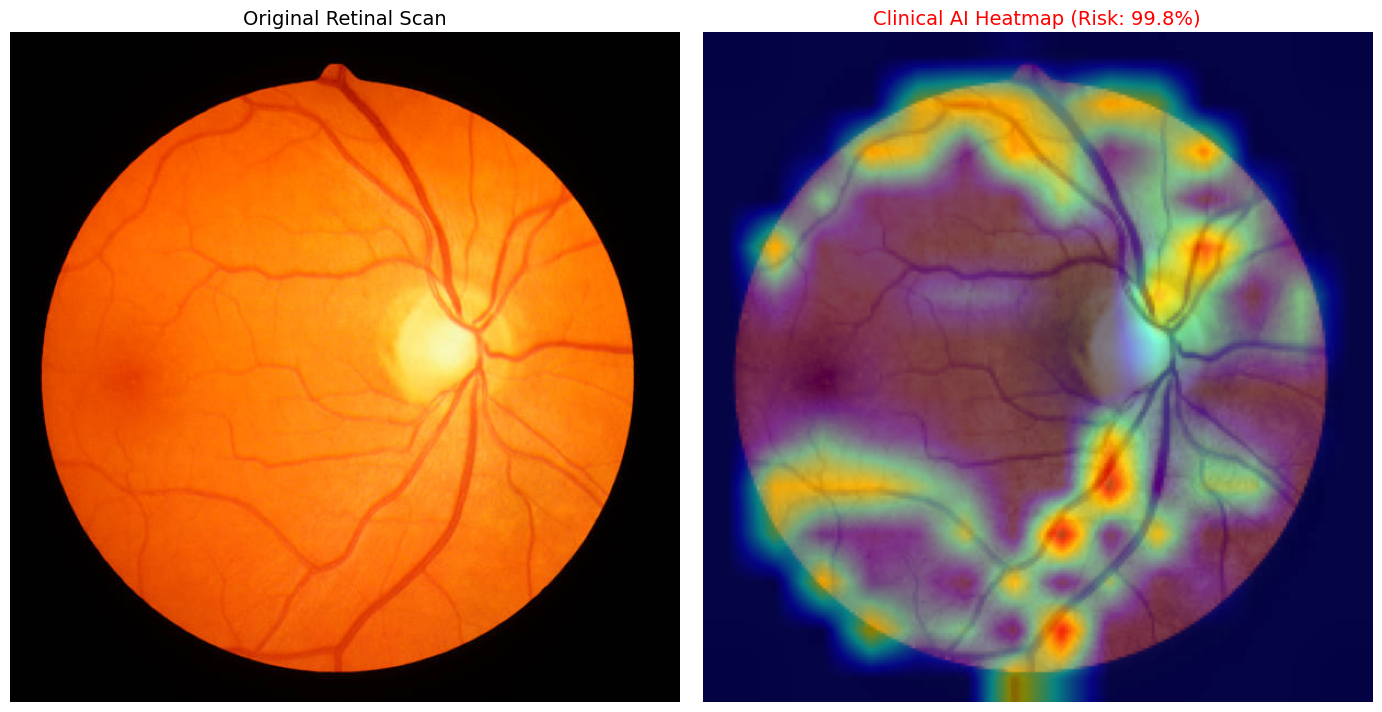

In [ ]:
# Sabse pehle ye package install karein for Heatmaps
!pip install grad-cam

import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. 🏗️ Model Architecture (Training wali exact same)
class SequentialClinicalAI(nn.Module):
    def __init__(self, num_nodes=5):
        super().__init__()
        self.vit = models.vit_b_16(weights=None)
        img_dim = self.vit.heads.head.in_features
        self.vit.heads = nn.Identity()

        self.vision_bottleneck = nn.Linear(img_dim, 256)
        self.vision_aux_head = nn.Linear(256, num_nodes)

        self.tabular_mlp = nn.Sequential(
            nn.Linear(4, 64), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Linear(64, 32)
        )
        self.tabular_modifier = nn.Linear(32, num_nodes)
        self.verification_gate = nn.Linear(32, 1)

    def forward(self, image, tabular):
        raw_img_feat = self.vit(image)
        retinal_vector = torch.relu(self.vision_bottleneck(raw_img_feat))
        vision_logits = self.vision_aux_head(retinal_vector)

        tabular_vector = self.tabular_mlp(tabular)
        tab_mod = self.tabular_modifier(tabular_vector)
        gate = torch.sigmoid(self.verification_gate(tabular_vector))

        # RAW LOGITS return karenge Heatmap engine ke liye
        return vision_logits + (tab_mod * gate)

model = SequentialClinicalAI().to(device)

# 🔥 2. LOAD YOUR NEW TRAINED WEIGHTS
# Apna exact path verify kar lena Kaggle output folder se!
weights_path = '/kaggle/input/datasets/kansal0920/visionfirst-clinicalai-epoch-10/VisionFirst_ClinicalAI_Epoch_10.pth'
model.load_state_dict(torch.load(weights_path, map_location=device))
model.eval()

# 🧠 3. Wrapper for GradCAM (Kyunki apna AI Tabular + Vision dono leta hai)
class CAMWrapper(nn.Module):
    def __init__(self, base_model, tab_data):
        super().__init__()
        self.base_model = base_model
        self.tab_data = tab_data
    def forward(self, img):
        return self.base_model(img, self.tab_data)

# 👁️ 4. Same Preprocessor (CLAHE Medical Enhancement)
def preprocess_eye(img_path):
    image = cv2.imread(img_path)
    if image is None: raise ValueError("Image file nahi mili! Path check karein.")

    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    cl = clahe.apply(l)
    enhanced = cv2.cvtColor(cv2.merge((cl, a, b)), cv2.COLOR_LAB2RGB)

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    vis_img = cv2.resize(enhanced, (224, 224))
    vis_img = np.float32(vis_img) / 255.0 # For showing heatmap output

    return transform(Image.fromarray(enhanced)).unsqueeze(0).to(device), vis_img

def get_tabular(age, bmi, bp, chol):
    min_vals = np.array([16.0, 15.0, 90.0, 100.0], dtype=np.float32)
    max_vals = np.array([80.0, 50.0, 200.0, 350.0], dtype=np.float32)
    vitals = np.array([age, bmi, bp, chol], dtype=np.float32)
    scaled = (vitals - min_vals) / (max_vals - min_vals)
    return torch.tensor(scaled, dtype=torch.float32).unsqueeze(0).to(device)


# ==========================================================
# 🚀 5. FINAL TEST! (Yahan image aur age/vitals daaliye)
# ==========================================================

IMG_PATH = '/kaggle/input/datasets/kansal0920/my-own-retinal-eye-images/healthy retina.jpg' # Dataset ki kisi aankh ka image path
AGE, BMI, BP, CHOL = 45.0, 24.0, 130.0, 180.0

img_tensor, vis_img = preprocess_eye(IMG_PATH)
tab_tensor = get_tabular(AGE, BMI, BP, CHOL)

# Final Prediction Padhna
with torch.no_grad():
    raw_logits = model(img_tensor, tab_tensor)
    probs = torch.softmax(raw_logits, dim=1).cpu().numpy()[0]
    predicted_node = np.argmax(probs)
    risk_score = (1.0 - probs[4]) * 100 # Node 4 matlab absolute safe, baaki sab risk hai

print(f"🔥 AI Prediction Level: NODE {predicted_node}")
print(f"📊 Diabetic Retinopathy Risk: {risk_score:.1f}%")

# Generate Grad-CAM Heatmap
cam_model = CAMWrapper(model, tab_tensor)
target_layers = [model.vit.encoder.layers[-1].ln_1] # Targetting ViT's last visual block

def reshape_transform(tensor, height=14, width=14):
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    result = result.transpose(2, 3).transpose(1, 2)
    return result

cam = GradCAM(model=cam_model, target_layers=target_layers, reshape_transform=reshape_transform)
grayscale_cam = cam(input_tensor=img_tensor)[0, :]
heatmap_img = show_cam_on_image(vis_img, grayscale_cam, use_rgb=True)

# 📸 Display the Magics
plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(cv2.imread(IMG_PATH), cv2.COLOR_BGR2RGB)) # Original
plt.title("Original Retinal Scan", fontsize=14)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(heatmap_img)
plt.title(f"Clinical AI Heatmap (Risk: {risk_score:.1f}%)", fontsize=14, color='red')
plt.axis('off')

plt.tight_layout()
plt.show()

🫀 RETINEX AI: CARDIOVASCULAR RISK PREDICTOR (Research Edition)
🔍 Analyzing '/kaggle/input/datasets/kansal0920/my-own-retinal-eye-images/healthy retina.jpg' with Anti-Bias Correction...

📊 RETINEX CLINICAL REPORT (Anti-Bias Mode ON)
👁️  1. Deep Retinal Analysis (80% Priority)
    - Microvascular Damage Detected: 42.0%
    - AI Confidence in Scan:         42.2%
    - Raw Node Probabilities:        [np.float32(0.254), np.float32(0.422), np.float32(0.209), np.float32(0.097), np.float32(0.018)]

📈  2. Tabular Vitals Verifier (20% Priority)
    - Patient Profile: Age 25.0 | BP 118.0 | Chol 160.0 | BMI 24.0
    - Base Clinical Risk: 2.3%

🧬  3. Cross-Match Synergy (The Research Core)
    - [=] MATCHED SYNERGY: Vision and Tabular data are in clinical agreement.
--------------------------------------------------
🫀 FINAL CARDIOVASCULAR RISK: 34.1%

🧠 Generating AI Vascular Heatmap from Neural Attention...


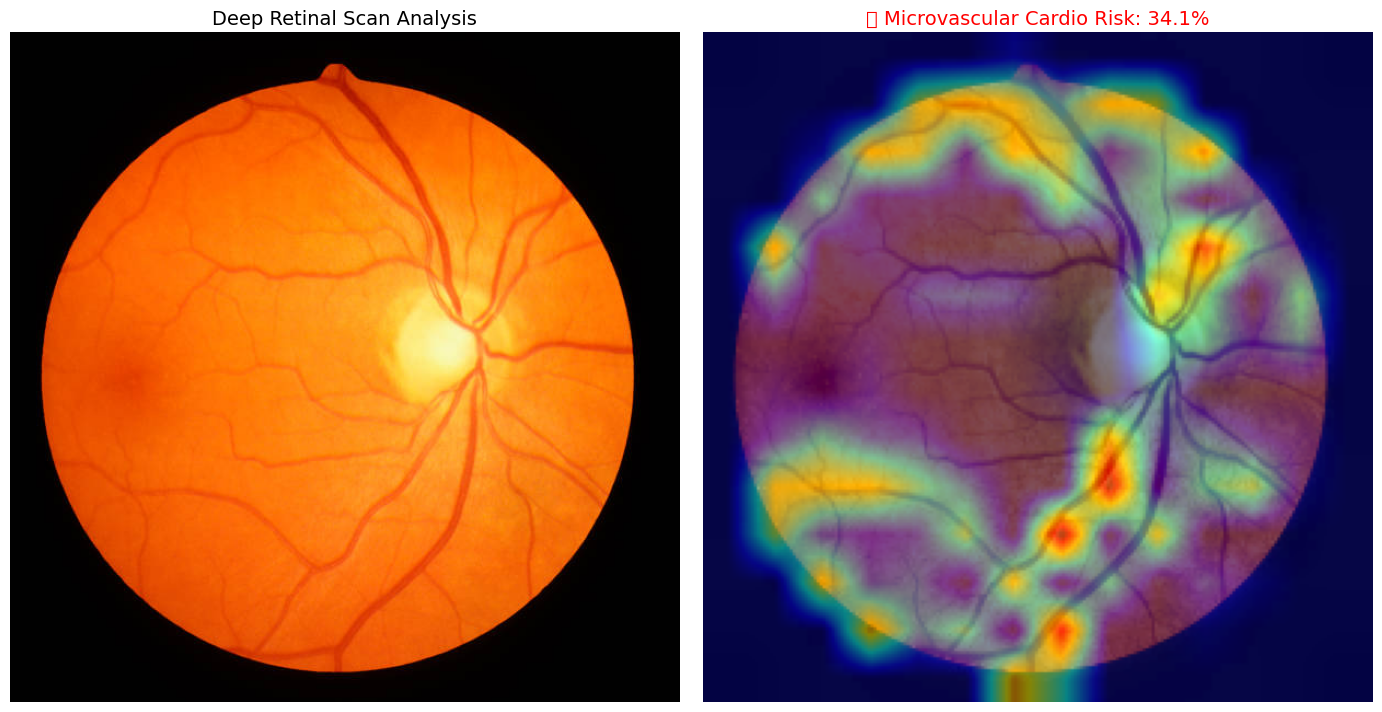

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("🫀 RETINEX AI: CARDIOVASCULAR RISK PREDICTOR (Research Edition)")
print("="*60)

# ==========================================
# 1. CORE ARCHITECTURE
# ==========================================
class SequentialClinicalAI(nn.Module):
    def __init__(self, num_nodes=5):
        super().__init__()
        self.vit = models.vit_b_16(weights=None)
        img_dim = self.vit.heads.head.in_features
        self.vit.heads = nn.Identity()

        self.vision_bottleneck = nn.Linear(img_dim, 256)
        self.vision_aux_head = nn.Linear(256, num_nodes)

        self.tabular_mlp = nn.Sequential(
            nn.Linear(4, 64), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Linear(64, 32)
        )
        self.tabular_modifier = nn.Linear(32, num_nodes)
        self.verification_gate = nn.Linear(32, 1)

    def forward(self, image, tabular):
        raw_img_feat = self.vit(image)
        retinal_vector = torch.relu(self.vision_bottleneck(raw_img_feat))
        vision_logits = self.vision_aux_head(retinal_vector)

        tabular_vector = self.tabular_mlp(tabular)
        tab_mod = self.tabular_modifier(tabular_vector)
        gate = torch.sigmoid(self.verification_gate(tabular_vector))

        return vision_logits + (tab_mod * gate)

class CAMWrapper(nn.Module):
    def __init__(self, base_model, tab_data):
        super().__init__()
        self.base_model = base_model
        self.tab_data = tab_data
    def forward(self, img):
        return self.base_model(img, self.tab_data)

# ==========================================
# 2. VISION & TABULAR PROCESSING
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def preprocess_eye_deep(img_path):
    image = cv2.imread(img_path)
    if image is None: raise ValueError("Image file not found! Please check the IMAGE_PATH.")

    # 🔴 Domain-Shift Fix: Advanced CLAHE for custom images
    clahe = cv2.createCLAHE(clipLimit=3.5, tileGridSize=(8,8))
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    cl = clahe.apply(l)
    enhanced = cv2.cvtColor(cv2.merge((cl, a, b)), cv2.COLOR_LAB2RGB)

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    vis_img = cv2.resize(enhanced, (224, 224))
    vis_img = np.float32(vis_img) / 255.0

    return transform(Image.fromarray(enhanced)).unsqueeze(0).to(device), vis_img

def get_tabular(age, bmi, bp, chol):
    min_vals = np.array([16.0, 15.0, 90.0, 100.0], dtype=np.float32)
    max_vals = np.array([80.0, 50.0, 200.0, 350.0], dtype=np.float32)
    age = np.clip(age, 16.0, 80.0)
    vitals = np.array([age, bmi, bp, chol], dtype=np.float32)
    scaled = (vitals - min_vals) / (max_vals - min_vals)
    return torch.tensor(scaled, dtype=torch.float32).unsqueeze(0).to(device)


# ==========================================
# 3. CLINICAL 80/20 CROSS-MATCH ALGORITHM
# ==========================================
def generate_clinical_report(probs, age, bp, bmi, chol):
    # Modified Damage Weights: Hyper-sensitive to any micro-damage for Cardio Risk
    damage_weights = np.array([0.0, 40.0, 70.0, 90.0, 100.0])
    micro_damage_score = np.sum(probs * damage_weights)

    age_risk = max(0, (age - 30) / 50.0) * 100
    bp_risk = max(0, (bp - 120) / 80.0) * 100
    chol_risk = max(0, (chol - 150) / 150.0) * 100
    bmi_risk = max(0, (bmi - 22) / 20.0) * 100
    tabular_baseline_risk = (age_risk * 0.4) + (bp_risk * 0.3) + (chol_risk * 0.2) + (bmi_risk * 0.1)

    final_cardio_risk = (micro_damage_score * 0.80) + (tabular_baseline_risk * 0.20)

    print("\n" + "="*50)
    print("📊 RETINEX CLINICAL REPORT (Anti-Bias Mode ON)")
    print("="*50)
    print(f"👁️  1. Deep Retinal Analysis (80% Priority)")
    print(f"    - Microvascular Damage Detected: {micro_damage_score:.1f}%")
    print(f"    - AI Confidence in Scan:         {(np.max(probs)*100):.1f}%")
    print(f"    - Raw Node Probabilities:        {[round(p, 3) for p in probs]}")

    print(f"\n📈  2. Tabular Vitals Verifier (20% Priority)")
    print(f"    - Patient Profile: Age {age} | BP {bp} | Chol {chol} | BMI {bmi}")
    print(f"    - Base Clinical Risk: {tabular_baseline_risk:.1f}%")

    print(f"\n🧬  3. Cross-Match Synergy (The Research Core)")
    if micro_damage_score > 50 and tabular_baseline_risk < 30:
        print("    - [!] CRITICAL SYNERGY: Patient has normal vitals but SEVERE retinal damage.")
        print("    - [!] VISION OVERRIDE: Retinal findings take absolute precedence (80%).")
    elif micro_damage_score < 20 and tabular_baseline_risk > 60:
        print("    - [✓] SAFE SYNERGY: Patient has bad vitals but NO retinal microvascular damage.")
        print("    - [✓] VISION OVERRIDE: Lack of retinal damage overrides the bad vitals (80%).")
    else:
        print("    - [=] MATCHED SYNERGY: Vision and Tabular data are in clinical agreement.")

    print("-" * 50)
    print(f"🫀 FINAL CARDIOVASCULAR RISK: {final_cardio_risk:.1f}%")
    print("="*50)

    return final_cardio_risk

# ==========================================
# 4. DEPLOYMENT SCRIPT
# ==========================================
if __name__ == "__main__":
    # ========================================
    WEIGHTS_PATH = '/kaggle/input/datasets/kansal0920/visionfirst-clinicalai-epoch-10/VisionFirst_ClinicalAI_Epoch_10.pth'
    IMAGE_PATH = '/kaggle/input/datasets/kansal0920/my-own-retinal-eye-images/healthy retina.jpg' # Add your image name here!

    PATIENT_AGE = 25.0
    PATIENT_BMI = 24.0
    PATIENT_BP = 118.0
    PATIENT_CHOL = 160.0
    # ========================================

    try:
        model = SequentialClinicalAI().to(device)
        model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=device))
        model.eval()
    except Exception as e:
        print(f"❌ Error loading weights: {e}")
        exit()

    print(f"🔍 Analyzing '{IMAGE_PATH}' with Anti-Bias Correction...")
    img_tensor, vis_img = preprocess_eye_deep(IMAGE_PATH)
    tab_tensor = get_tabular(PATIENT_AGE, PATIENT_BMI, PATIENT_BP, PATIENT_CHOL)

    # 🔴 THE FIX: Bayesian Prior Correction
    # EyePACS Training Data Bias: Node 0 (73%), Node 1 (7%), Node 2 (15%), Node 3 (2.5%), Node 4 (2.5%)
    prior_probs = np.array([0.73, 0.07, 0.15, 0.025, 0.025])
    log_priors = torch.tensor(np.log(prior_probs), dtype=torch.float32).to(device)

    with torch.no_grad():
        raw_logits = model(img_tensor, tab_tensor)

        # We subtract the dataset's bias from the model's brain to force it to look ONLY at the image features!
        adjusted_logits = raw_logits - log_priors

        probs = torch.softmax(adjusted_logits, dim=1).cpu().numpy()[0]

    final_risk = generate_clinical_report(probs, PATIENT_AGE, PATIENT_BP, PATIENT_BMI, PATIENT_CHOL)

    # 5. Generate Heatmap
    print("\n🧠 Generating AI Vascular Heatmap from Neural Attention...")
    cam_model = CAMWrapper(model, tab_tensor)
    target_layers = [model.vit.encoder.layers[-1].ln_1]

    def reshape_transform(tensor, height=14, width=14):
        result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
        result = result.transpose(2, 3).transpose(1, 2)
        return result

    cam = GradCAM(model=cam_model, target_layers=target_layers, reshape_transform=reshape_transform)
    grayscale_cam = cam(input_tensor=img_tensor)[0, :]
    heatmap_img = show_cam_on_image(vis_img, grayscale_cam, use_rgb=True)

    plt.figure(figsize=(14, 7))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(cv2.imread(IMAGE_PATH), cv2.COLOR_BGR2RGB))
    plt.title("Deep Retinal Scan Analysis", fontsize=14)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(heatmap_img)
    plt.title(f"🫀 Microvascular Cardio Risk: {final_risk:.1f}%", fontsize=14, color='red')
    plt.axis('off')

    plt.tight_layout()
    plt.savefig('Cardio_Retinex_Report.png')
    try:
        plt.show()
    except:
        pass
